# PulseOps NHS Data Analysis

This notebook is an **exploratory analysis artifact**, not production logic. It answers:

- what the 15 raw files contain and how they relate;
- whether the data is complete, consistent, and forecastable;
- which organisations have enough history;
- which variables can become features;
- what target is realistic for the first forecasting model.

Raw files are loaded from `data/raw/` and are never modified. Reusable validation and transformation logic belongs in `src/`; this notebook is for inspection, visualization, and decisions.

In [2]:
from __future__ import annotations

from pathlib import Path
import hashlib
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid", context="notebook", palette="deep")

NOTEBOOK_PATH = Path.cwd()
if NOTEBOOK_PATH.name == "notebooks":
    PROJECT_ROOT = NOTEBOOK_PATH.parent
elif (NOTEBOOK_PATH / "data" / "raw").exists():
    PROJECT_ROOT = NOTEBOOK_PATH
else:
    PROJECT_ROOT = Path("..").resolve()

RAW_ROOT = PROJECT_ROOT / "data" / "raw"
INTERIM_ROOT = PROJECT_ROOT / "data" / "interim"
PROCESSED_ROOT = PROJECT_ROOT / "data" / "processed"

DATASETS = {
    "beds": RAW_ROOT / "beds",
    "discharges": RAW_ROOT / "discharges",
    "admissions": RAW_ROOT / "admissions",
}

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data root: {RAW_ROOT}")
print("CSV counts:", {name: len(list(path.glob("*.csv"))) for name, path in DATASETS.items()})

Project root: c:\Users\ACER\OneDrive\Desktop\PulseOps
Raw data root: c:\Users\ACER\OneDrive\Desktop\PulseOps\data\raw
CSV counts: {'beds': 5, 'discharges': 5, 'admissions': 5}


## 1. Load the raw files and build an inventory

The raw layer contains three different collection designs:

- **Beds:** daily, long format, with metrics in rows.
- **Discharges:** daily, long format, with metric type/group dimensions.
- **Admissions:** monthly, wide provider-level measures.

The files are concatenated only into in-memory analytical tables. Nothing is written back to `data/raw/`.

In [3]:
def file_sha256(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def read_raw_csv(path: Path) -> tuple[pd.DataFrame, str]:
    """Read an untouched source file while making its encoding explicit."""
    for encoding in ("utf-8", "utf-8-sig", "cp1252"):
        try:
            return pd.read_csv(path, encoding=encoding, low_memory=False), encoding
        except UnicodeDecodeError:
            continue
    raise UnicodeDecodeError("unknown", b"", 0, 1, f"Could not decode {path}")


inventory_rows = []
raw_frames: dict[str, list[pd.DataFrame]] = {name: [] for name in DATASETS}

for source, folder in DATASETS.items():
    for path in sorted(folder.glob("*.csv")):
        frame, encoding = read_raw_csv(path)
        frame.columns = [str(column).strip() for column in frame.columns]
        frame["_source_file"] = path.name
        frame["_source"] = source
        raw_frames[source].append(frame)
        inventory_rows.append(
            {
                "source": source,
                "file": path.name,
                "rows": len(frame),
                "columns": len(frame.columns) - 2,
                "encoding": encoding,
                "size_mb": path.stat().st_size / 1_000_000,
                "sha256": file_sha256(path),
                "modified_at": pd.Timestamp(path.stat().st_mtime, unit="s"),
            }
        )

inventory = pd.DataFrame(inventory_rows).sort_values(["source", "file"]).reset_index(drop=True)
inventory[["source", "file", "rows", "columns", "encoding", "size_mb", "modified_at"]]

,source,file,rows,columns,encoding,size_mb,modified_at
0,admissions,April-2026-CSV-QD21vf.csv,191,22,utf-8,0.027915,2026-09-15 12:26:02.268665314
1,admissions,August-2026-CSV-De2k3n.csv,192,22,utf-8,0.028180,2026-09-15 12:26:13.355010986
2,admissions,July-2026-CSV-Trf28h.csv,192,22,utf-8,0.027845,2026-09-15 12:26:10.110958576
3,admissions,June-2026-CSV-Wfg38l.csv,193,22,utf-8,0.027989,2026-09-15 12:26:08.069699526
4,admissions,May-2026-CSV-F4flrg.csv,193,22,utf-8,0.027775,2026-09-15 12:26:03.994295359
5,beds,202604-April-2026-beds-sitrep-data-finalversio...,8028,11,utf-8,1.376476,2026-09-15 12:16:24.023796320
6,beds,202605-May-2026-beds-sitrep-data-finalversion.csv,8100,11,utf-8,1.460688,2026-09-15 12:16:25.180095673
7,beds,202606-June-2026-beds-sitrep-data-finalversion...,8028,11,utf-8,1.376241,2026-09-15 12:16:26.012131214
8,beds,202607-July-2026-beds-sitrep-data-finalversion...,7992,11,utf-8,1.368201,2026-09-15 12:16:26.822269917
9,beds,202608-August-2026-beds-sitrep-data-provisiona...,7992,11,utf-8,1.368181,2026-09-15 12:16:28.554872990


In [4]:
frames = {source: pd.concat(parts, ignore_index=True) for source, parts in raw_frames.items()}

for source, frame in frames.items():
    print(f"{source:12} shape={frame.shape}  memory={frame.memory_usage(deep=True).sum() / 1_000_000:.1f} MB")

print("\nColumns by source")
for source, frame in frames.items():
    print(f"\n{source.upper()}:\n", list(frame.columns))

beds         shape=(40140, 13)  memory=32.3 MB
discharges   shape=(183883, 12)  memory=186.2 MB
admissions   shape=(961, 24)  memory=0.6 MB

Columns by source

BEDS:
 ['Period', 'Level', 'Region', 'ICB', 'Org Code', 'Org Name', 'Metric', 'Type', 'Value', 'Unnamed: 9', 'Unnamed: 10', '_source_file', '_source']

DISCHARGES:
 ['Period', 'Level', 'Region', 'ICB', 'Org Code', 'Org Name', 'Metric', 'Metric Type', 'Metric Group', 'Value', '_source_file', '_source']

ADMISSIONS:
 ['Period', 'Org Code', 'Parent Org', 'Org name', 'A&E attendances Type 1', 'A&E attendances Type 2', 'A&E attendances Other A&E Department', 'A&E attendances Booked Appointments Type 1', 'A&E attendances Booked Appointments Type 2', 'A&E attendances Booked Appointments Other Department', 'Attendances over 4hrs Type 1', 'Attendances over 4hrs Type 2', 'Attendances over 4hrs Other Department', 'Attendances over 4hrs Booked Appointments Type 1', 'Attendances over 4hrs Booked Appointments Type 2', 'Attendances over 4hrs B

## 2. Schema, completeness, and data-quality audit

This section answers the basic reliability questions before any modeling decision: columns, row counts, missing values, duplicate records, date coverage, and organisation coverage.

In [5]:
def parse_periods(frame: pd.DataFrame, source: str) -> pd.Series:
    if source == "admissions":
        extracted = frame["Period"].astype(str).str.extract(r"(?i)(JANUARY|FEBRUARY|MARCH|APRIL|MAY|JUNE|JULY|AUGUST|SEPTEMBER|OCTOBER|NOVEMBER|DECEMBER)[^0-9]*(202[0-9])")
        return pd.to_datetime(extracted[0] + " " + extracted[1], format="%B %Y", errors="coerce")
    return pd.to_datetime(frame["Period"], dayfirst=True, errors="coerce")


summary_rows = []
for source, frame in frames.items():
    parsed_dates = parse_periods(frame, source)
    summary_rows.append(
        {
            "source": source,
            "rows": len(frame),
            "columns": len(frame.columns) - 2,
            "missing_cells": int(frame.drop(columns=["_source_file", "_source"]).isna().sum().sum()),
            "duplicate_rows": int(frame.duplicated().sum()),
            "invalid_periods": int(parsed_dates.isna().sum()),
            "period_start": parsed_dates.min(),
            "period_end": parsed_dates.max(),
            "organisations": int(frame["Org Code"].nunique()) if "Org Code" in frame else np.nan,
        }
    )

quality_summary = pd.DataFrame(summary_rows).set_index("source")
quality_summary

,rows,columns,missing_cells,duplicate_rows,invalid_periods,period_start,period_end,organisations
source,,,,,,,,
beds,40140,11,81900,175,180,2026-04-01,2026-08-01,179
discharges,183883,10,0,0,0,2026-03-30,2026-08-31,162
admissions,961,22,0,0,5,2026-04-01,2026-08-01,195


In [6]:
def missingness_table(frame: pd.DataFrame) -> pd.DataFrame:
    audit = pd.DataFrame(
        {
            "missing": frame.isna().sum(),
            "missing_pct": frame.isna().mean().mul(100).round(2),
            "unique_values": frame.nunique(dropna=False),
            "dtype": frame.dtypes.astype(str),
        }
    )
    return audit.sort_values(["missing_pct", "unique_values"], ascending=[False, True])


for source, frame in frames.items():
    parsed = parse_periods(frame, source)
    invalid = frame.loc[parsed.isna(), "Period"].value_counts(dropna=False).head(10)
    if len(invalid):
        print(f"{source.upper()} non-date period values:")
        display(invalid.rename("rows").to_frame())

print("Bed columns with missing values")
display(missingness_table(frames["beds"]).query("missing > 0"))
print("Exact duplicate rows")
quality_summary[["duplicate_rows"]]

BEDS non-date period values:


,rows
Period,
NaN,180


ADMISSIONS non-date period values:


,rows
Period,
TOTAL,2
Total,2
TOTAL,1


Bed columns with missing values


,missing,missing_pct,unique_values,dtype
Unnamed: 9,40140,100.00,1,float64
Unnamed: 10,40140,100.00,1,float64
Type,180,0.45,4,object
Level,180,0.45,5,object
Period,180,0.45,6,object
Region,180,0.45,9,object
Metric,180,0.45,37,object
ICB,180,0.45,38,object
Org Code,180,0.45,180,object
Org Name,180,0.45,217,object


Exact duplicate rows


,duplicate_rows
source,
beds,175
discharges,0
admissions,0


## 3. Bed capacity and occupancy

Bed data is long format. The first job is to understand the metric vocabulary and distinguish daily organisation records from national, regional, and ICB aggregates. We will calculate occupancy only where the source provides compatible available and occupied measures.

In [7]:
beds = frames["beds"].copy()
beds["date"] = parse_periods(beds, "beds")
beds["value_numeric"] = pd.to_numeric(beds["Value"], errors="coerce")

print("Bed metrics")
display(beds["Metric"].value_counts().rename("rows").to_frame())
print("Bed levels")
display(beds["Level"].value_counts(dropna=False).rename("rows").to_frame())
print("Bed types")
display(beds["Type"].value_counts(dropna=False).rename("rows").to_frame())

Bed metrics


,rows
Metric,
G&A beds available,1110
G&A core beds available,1110
Paediatric G&A occupancy rate adjusted for covid void beds,1110
Adult critical care beds available,1110
Adult critical care beds occupied,1110
Adult critical care occupancy rate,1110
Paediatric intensive care beds available,1110
Paediatric intensive care beds occupied,1110
Paediatric intensive care occupancy rate,1110


Bed levels


,rows
Level,
Provider,24048
ICB,13032
Region,2520
National,360
NaN,180


Bed types


,rows
Type,
Type 1,29664
All Type,7956
Other,2340
NaN,180


In [8]:
bed_metric_pivot = (
    beds.dropna(subset=["date", "Org Code"])
    .pivot_table(
        index=["date", "Level", "Org Code", "Org Name", "Type"],
        columns="Metric",
        values="value_numeric",
        aggfunc="first",
    )
    .reset_index()
)

metric_names = [str(column) for column in bed_metric_pivot.columns]
rate_candidates = [column for column in metric_names if "G&A occupancy rate" == column]
available_candidates = [column for column in metric_names if "G&A beds available" == column]
occupied_candidates = [column for column in metric_names if "G&A beds occupied" == column]
print("G&A available candidates:", available_candidates)
print("G&A occupied candidates:", occupied_candidates)
print("Direct occupancy-rate candidates:", rate_candidates)

if rate_candidates:
    bed_metric_pivot["occupancy_rate"] = bed_metric_pivot[rate_candidates[0]]
    print("Using the source-provided G&A occupancy rate.")
elif available_candidates and occupied_candidates:
    available_column = available_candidates[0]
    occupied_column = occupied_candidates[0]
    bed_metric_pivot["occupancy_rate"] = (
        bed_metric_pivot[occupied_column] / bed_metric_pivot[available_column]
    ).where(bed_metric_pivot[available_column] > 0)
    print("Calculated occupancy as occupied / available.")
else:
    bed_metric_pivot["occupancy_rate"] = np.nan
    print("No compatible G&A occupancy metric pair was found.")

display(bed_metric_pivot["occupancy_rate"].describe(percentiles=[.01, .05, .5, .95, .99]).to_frame())

G&A available candidates: ['G&A beds available']
G&A occupied candidates: ['G&A beds occupied']
Direct occupancy-rate candidates: ['G&A occupancy rate']
Using the source-provided G&A occupancy rate.


,occupancy_rate
count,1110.000000
mean,194.223585
std,853.136303
min,0.000000
1%,0.608180
5%,0.820000
50%,0.937000
95%,1395.005500
99%,5650.865600
max,6600.230000


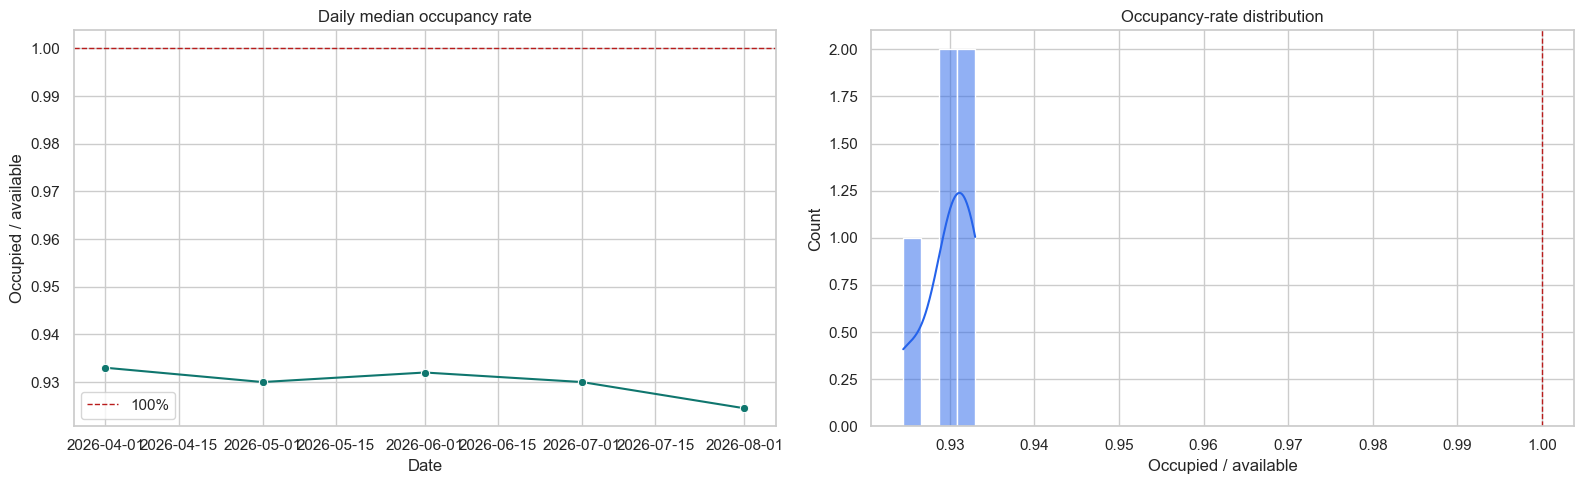

In [12]:
def plot_bed_trends(bed_table: pd.DataFrame) -> None:
    national = bed_table[bed_table["Level"].astype(str).str.lower().eq("national")].copy()
    if national.empty:
        national = bed_table.copy()
    trend = national.groupby("date", as_index=False)["occupancy_rate"].median().dropna()
    if trend.empty:
        print("No occupancy-rate series available to plot.")
        return
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.lineplot(data=trend, x="date", y="occupancy_rate", marker="o", ax=axes[0], color="#0f766e")
    axes[0].axhline(1, color="#b91c1c", linestyle="--", linewidth=1, label="100%")
    axes[0].set(title="Daily median occupancy rate", ylabel="Occupied / available", xlabel="Date")
    axes[0].legend()
    sns.histplot(trend["occupancy_rate"], kde=True, ax=axes[1], color="#2563eb")
    axes[1].axvline(1, color="#b91c1c", linestyle="--", linewidth=1)
    axes[1].set(title="Occupancy-rate distribution", xlabel="Occupied / available")
    plt.tight_layout()
    plt.show()


plot_bed_trends(bed_metric_pivot)

## 4. Discharge flow and A&E demand

Discharges are daily and long-format; A&E admissions are monthly and wide-format. They can provide context for a daily occupancy model, but they do not have the same temporal resolution. The plots below keep those granularities visible.

In [9]:
discharges = frames["discharges"].copy()
discharges["date"] = parse_periods(discharges, "discharges")
discharges["value_numeric"] = pd.to_numeric(discharges["Value"], errors="coerce")

print("Most common discharge metrics")
discharge_metrics = discharges.groupby(["Metric", "Metric Type", "Metric Group"], dropna=False).agg(
    rows=("value_numeric", "size"),
    organisations=("Org Code", "nunique"),
    dates=("date", "nunique"),
    missing_values=("value_numeric", lambda series: int(series.isna().sum())),
).sort_values("rows", ascending=False)
display(discharge_metrics.head(25))

# National daily totals for the most common metric groups.
national_discharges = discharges[
    discharges["Level"].astype(str).str.lower().eq("national")
].groupby(["date", "Metric"], as_index=False)["value_numeric"].sum(min_count=1)
print("National discharge series")
display(national_discharges.head())

Most common discharge metrics


rows  organisations  dates  \
Metric                                             Metric Type            Metric Group                                             
Number of patients who no longer meet the crite... Daily metric           NCTR                       24886            162    153   
Number of patients remaining in hospital who no... Daily metric           NCTR not discharged        24886            162    153   
Number of patients discharged                      Daily metric           Discharges                 24886            162    153   
Number of additional bed days, patients with le... Weekly snapshot metric Additional bed days lost    3553            162     22   
Number of additional bed days, patients with le... Weekly snapshot metric Additional bed days lost    3553            162     22   
Number of additional bed days, patients with le... Weekly snapshot metric Additional bed days lost    3553            162     22   
InterfaceÂ process â€“ Further action requested by... Weekly snapshot metric Delay reason LOS 14+         808            162      5   
                                                                          Delay reason LOS 7+          808            162      5   
Capacity â€“ Awaiting restart of existing social ... Weekly snapshot metric Delay reason LOS 14+         808            162      5   
InterfaceÂ process â€“ Out of area discharge arran... Weekly snapshot metric Delay reason LOS 14+         808            162      5   
InterfaceÂ process â€“ Further action requested by... Weekly snapshot metric Delay reason LOS 7+ Costs    808            162      5   
InterfaceÂ process â€“ Homeless with no recourse t... Weekly snapshot metric Delay reason LOS 14+         808            162      5   
                                                                          Delay reason LOS 7+          808            162      5   
                                                                          Delay reason LOS 7+ Costs    808            162      5   
InterfaceÂ process â€“ Housing provision arrangeme... Weekly snapshot metric Delay reason LOS 14+         808            162      5   
                                                                          Delay reason LOS 7+          808            162      5   
InterfaceÂ process â€“ End of life care inc Fast-T... Weekly snapshot metric Delay reason LOS 7+ Costs    808            162      5   
                                                                          Delay reason LOS 7+          808            162      5   
                                                                          Delay reason LOS 14+         808            162      5   
Interface process â€“ Residential/nursing home ca... Weekly snapshot metric Delay reason LOS 7+ Costs    808            162      5   
                                                                          Delay reason LOS 7+          808            162      5   
                                                                          Delay reason LOS 14+         808            162      5   
Interface process â€“ Other home-based social car... Weekly snapshot metric Delay reason LOS 7+ Costs    808            162      5   
                                                                          Delay reason LOS 7+          808            162      5   
                                                                          Delay reason LOS 14+         808            162      5   

                                                                                                     missing_values  
Metric                                             Metric Type            Metric Group                               
Number of patients who no longer meet the crite... Daily metric           NCTR                                  196  
Number of patients remaining in hospital who no... Daily metric           NCTR not discharged                   196  
Number of patients discharged            

National discharge series


,date,Metric,value_numeric
0,2026-03-30,"Number of additional bed days, patients with l...",127645.00
1,2026-03-30,"Number of additional bed days, patients with l...",113060.00
2,2026-03-30,"Number of additional bed days, patients with l...",137480.00
3,2026-04-01,Capacity â€“ Awaiting restart of existing social...,2301902.38
4,2026-04-01,"Capacity â€“ Bed-based rehabilitation, reablemen...",18767879.81


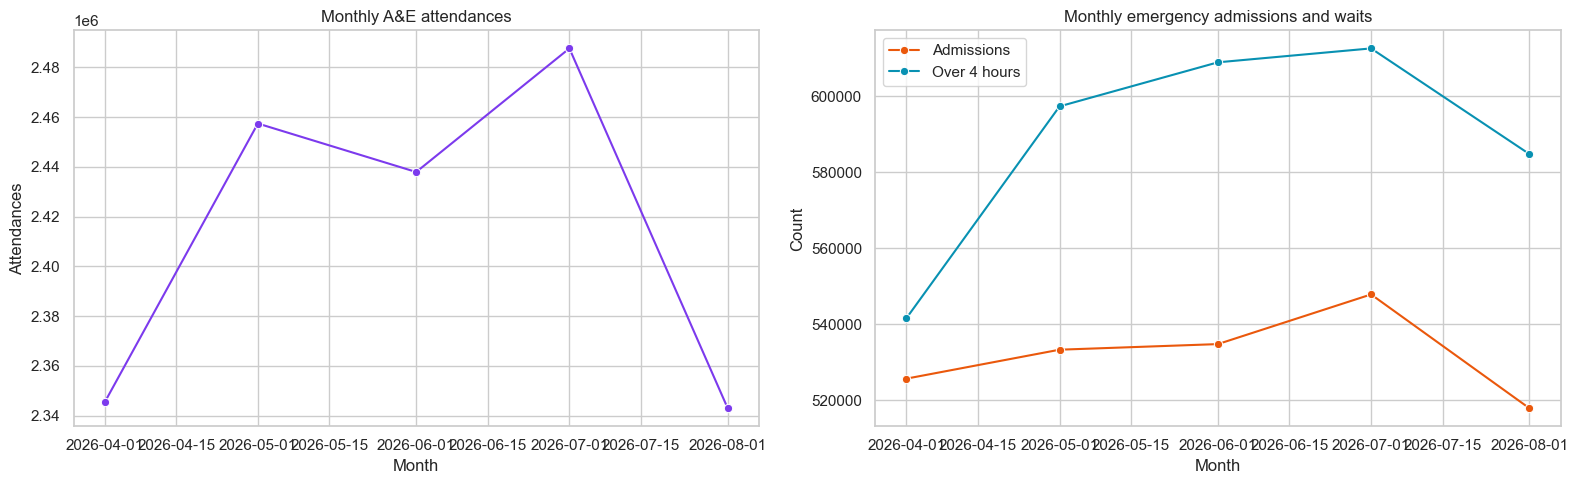

,month,total_attendances,total_emergency_admissions,total_over_4_hours
0,2026-04-01,2345329,525660,541542
1,2026-05-01,2457398,533280,597323
2,2026-06-01,2437906,534753,608917
3,2026-07-01,2487580,547828,612579
4,2026-08-01,2342959,517868,584767


In [10]:
admissions = frames["admissions"].copy()
admissions["month"] = parse_periods(admissions, "admissions")
admissions = admissions[admissions["month"].notna()].copy()
admissions["month"] = admissions["month"].dt.to_period("M").dt.to_timestamp()

admission_measure_columns = [
    column for column in admissions.columns
    if column not in {"Period", "Org Code", "Parent Org", "Org name", "month", "_source_file", "_source"}
]
for column in admission_measure_columns:
    admissions[column] = pd.to_numeric(admissions[column], errors="coerce")

admissions["total_attendances"] = admissions.filter(regex=r"^A&E attendances").sum(axis=1, min_count=1)
admissions["total_emergency_admissions"] = admissions.filter(regex=r"^Emergency admissions|^Other emergency admissions").sum(axis=1, min_count=1)
admissions["total_over_4_hours"] = admissions.filter(regex=r"^Attendances over 4hrs").sum(axis=1, min_count=1)

monthly_admissions = admissions.groupby("month", as_index=False)[
    ["total_attendances", "total_emergency_admissions", "total_over_4_hours"]
].sum(min_count=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=monthly_admissions, x="month", y="total_attendances", marker="o", ax=axes[0], color="#7c3aed")
axes[0].set(title="Monthly A&E attendances", ylabel="Attendances", xlabel="Month")
sns.lineplot(data=monthly_admissions, x="month", y="total_emergency_admissions", marker="o", ax=axes[1], color="#ea580c", label="Admissions")
sns.lineplot(data=monthly_admissions, x="month", y="total_over_4_hours", marker="o", ax=axes[1], color="#0891b2", label="Over 4 hours")
axes[1].set(title="Monthly emergency admissions and waits", ylabel="Count", xlabel="Month")
plt.tight_layout()
plt.show()
monthly_admissions

## 5. Daily, weekly, and seasonal patterns

Five months is too short to claim annual seasonality. We can still inspect weekday effects, within-period variation, and whether the daily series has enough repeated observations for lag and rolling-window features.

In [11]:
date_coverage = pd.DataFrame(
    {
        source: {
            "unique_periods": parse_periods(frame, source).nunique(),
            "first_period": parse_periods(frame, source).min(),
            "last_period": parse_periods(frame, source).max(),
            "rows_per_period_median": parse_periods(frame, source).value_counts().median(),
        }
        for source, frame in frames.items()
    }
)
date_coverage

,beds,discharges,admissions
unique_periods,5,154,5
first_period,2026-04-01 00:00:00,2026-03-30 00:00:00,2026-04-01 00:00:00
last_period,2026-08-01 00:00:00,2026-08-31 00:00:00,2026-08-01 00:00:00
rows_per_period_median,7992.0,486.0,191.0


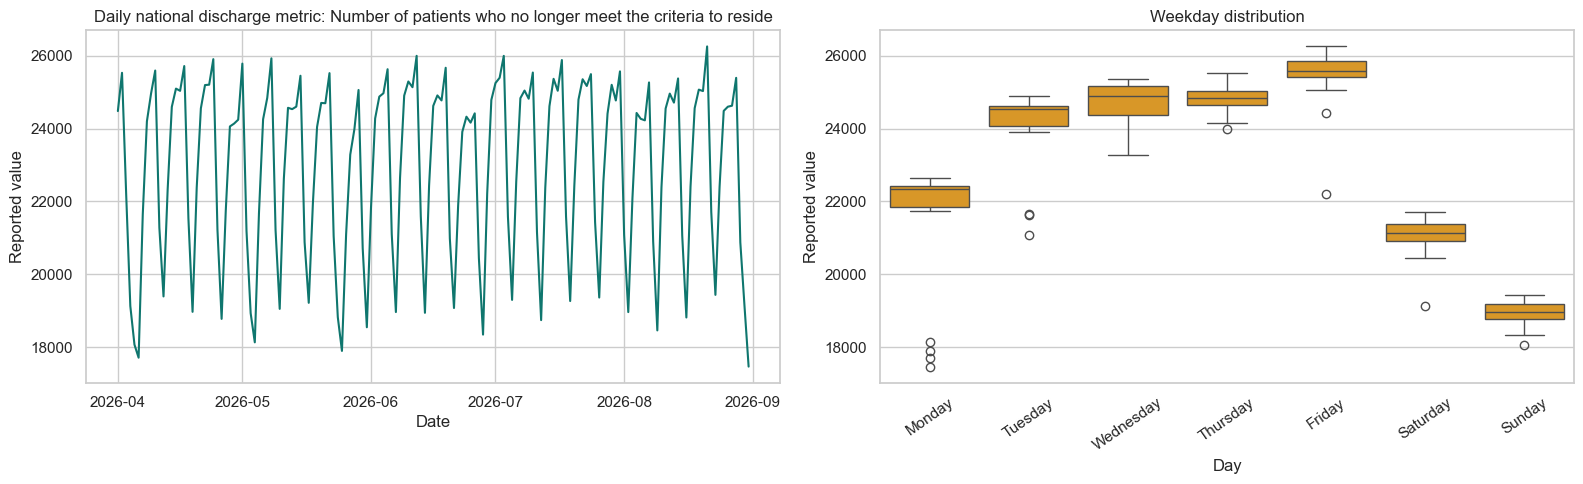

In [17]:
# Create a national daily discharge view for trend analysis.
daily_discharge = (
    discharges[discharges["Level"].astype(str).str.lower().eq("national")]
    .groupby(["date", "Metric"], as_index=False)["value_numeric"]
    .sum(min_count=1)
)

if not daily_discharge.empty:
    top_metric = daily_discharge["Metric"].value_counts().index[0]
    top_discharge_series = daily_discharge[daily_discharge["Metric"].eq(top_metric)].copy()
    top_discharge_series["day_of_week"] = top_discharge_series["date"].dt.day_name()
    top_discharge_series["week"] = top_discharge_series["date"].dt.to_period("W").dt.start_time
    weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.lineplot(data=top_discharge_series, x="date", y="value_numeric", ax=axes[0], color="#0f766e")
    axes[0].set(title=f"Daily national discharge metric: {top_metric}", ylabel="Reported value", xlabel="Date")
    weekday_values = top_discharge_series.assign(day_of_week=pd.Categorical(top_discharge_series["day_of_week"], categories=weekday_order, ordered=True))
    sns.boxplot(data=weekday_values, x="day_of_week", y="value_numeric", ax=axes[1], color="#f59e0b")
    axes[1].tick_params(axis="x", rotation=35)
    axes[1].set(title="Weekday distribution", ylabel="Reported value", xlabel="Day")
    plt.tight_layout()
    plt.show()
else:
    print("No national discharge rows available for trend analysis.")

## 6. Correlations and outliers

Correlations are descriptive, not causal. They are especially fragile here because bed occupancy and A&E demand have only five monthly periods. Outlier checks therefore focus on impossible occupancy values, extreme provider values, duplicate keys, and unusually large discharge observations.

In [19]:
provider_occupancy = bed_metric_pivot[
    bed_metric_pivot["Level"].astype(str).str.lower().eq("provider")
    & bed_metric_pivot["occupancy_rate"].notna()
].copy()

occupancy_outliers = provider_occupancy[
    (provider_occupancy["occupancy_rate"] < 0) | (provider_occupancy["occupancy_rate"] > 1)
].sort_values("occupancy_rate", ascending=False)
print(f"Provider occupancy records outside [0, 1]: {len(occupancy_outliers):,}")
display(occupancy_outliers[["date", "Org Code", "Org Name", "Type", "occupancy_rate"]].head(20))

# IQR outliers among plausible provider occupancy rates.
plausible = provider_occupancy[provider_occupancy["occupancy_rate"].between(0, 1)].copy()
q1, q3 = plausible["occupancy_rate"].quantile([0.25, 0.75])
iqr = q3 - q1
iqr_outliers = plausible[
    (plausible["occupancy_rate"] < q1 - 1.5 * iqr)
    | (plausible["occupancy_rate"] > q3 + 1.5 * iqr)
]
print(f"Plausible provider occupancy IQR outliers: {len(iqr_outliers):,}")

# Only merge at a common date after aggregating each source to a clear grain.
national_bed = (
    bed_metric_pivot[bed_metric_pivot["Level"].astype(str).str.lower().eq("national")]
    .groupby("date", as_index=False)["occupancy_rate"].median()
    .rename(columns={"occupancy_rate": "national_occupancy"})
)
national_discharge = (
    discharges[
        discharges["Level"].astype(str).str.lower().eq("national")
        & discharges["Metric"].isin(["Number of patients discharged", "Number of patients who no longer meet the criteria to reside"])
    ]
    .pivot_table(index="date", columns="Metric", values="value_numeric", aggfunc="sum")
    .reset_index()
)
correlation_view = national_bed.merge(national_discharge, on="date", how="inner")
print(f"Common bed/discharge periods for correlation: {len(correlation_view)}")
if len(correlation_view) >= 3:
    display(correlation_view.corr(numeric_only=True).round(3))
else:
    print("Too few common periods for a reliable correlation estimate.")

Provider occupancy records outside [0, 1]: 0


Metric,date,Org Code,Org Name,Type,occupancy_rate


Plausible provider occupancy IQR outliers: 59
Common bed/discharge periods for correlation: 5


,national_occupancy,Number of patients discharged,Number of patients who no longer meet the criteria to reside
national_occupancy,1.000,0.527,0.470
Number of patients discharged,0.527,1.000,0.993
Number of patients who no longer meet the criteria to reside,0.470,0.993,1.000


## 7. Feature engineering candidates

The candidate features below are deliberately separated into **safe to build now**, **possible after normalization**, and **not supported by the current time span**. Any lag or rolling feature must be calculated after sorting by organisation and date, with no future information leaking into the row.

In [21]:
feature_decision = pd.DataFrame(
    [
        ["date", "Beds/discharges", "safe now", "Parse source-specific Period into a canonical date."],
        ["organisation_id", "All sources", "safe now", "Use Org Code; retain Org Name only for display."],
        ["occupancy_rate", "Beds", "safe after checks", "Prefer source G&A occupancy rate; validate plausible range and level."],
        ["available_beds / occupied_beds", "Beds", "safe after normalization", "Pivot long metrics at organisation-date grain."],
        ["daily_discharges", "Discharges", "safe now", "Use Number of patients discharged at organisation-date grain."],
        ["nctr / delayed-flow metrics", "Discharges", "safe after metric selection", "Keep daily metrics separate from weekly snapshot metrics."],
        ["day_of_week / is_weekend", "Daily sources", "safe now", "Calendar features are available for March-August daily discharge data."],
        ["lag_1 / lag_7 / rolling_7d", "Daily target", "safe after target choice", "Create within organisation after sorting; require adequate history."],
        ["monthly A&E context", "Admissions", "possible", "Join as month-level context; do not pretend it is daily."],
        ["annual seasonality", "All sources", "not supported", "Five months is insufficient for annual seasonal inference."],
    ],
    columns=["candidate", "source", "status", "rationale"],
)
display(feature_decision)

# Example leakage-safe feature function for exploratory use only.
def add_time_features(table: pd.DataFrame, target_column: str) -> pd.DataFrame:
    result = table.sort_values(["Org Code", "date"]).copy()
    grouped = result.groupby("Org Code", group_keys=False)[target_column]
    result["day_of_week"] = result["date"].dt.dayofweek
    result["is_weekend"] = result["day_of_week"].isin([5, 6]).astype(int)
    result["lag_1"] = grouped.shift(1)
    result["lag_7"] = grouped.shift(7)
    result["rolling_7d_mean"] = grouped.transform(lambda values: values.shift(1).rolling(7, min_periods=4).mean())
    return result

print("Feature function defined for exploration; production implementation belongs in src/pulseops/data or src/pulseops/features.")

,candidate,source,status,rationale
0,date,Beds/discharges,safe now,Parse source-specific Period into a canonical ...
1,organisation_id,All sources,safe now,Use Org Code; retain Org Name only for display.
2,occupancy_rate,Beds,safe after checks,Prefer source G&A occupancy rate; validate pla...
3,available_beds / occupied_beds,Beds,safe after normalization,Pivot long metrics at organisation-date grain.
4,daily_discharges,Discharges,safe now,Use Number of patients discharged at organisat...
5,nctr / delayed-flow metrics,Discharges,safe after metric selection,Keep daily metrics separate from weekly snapsh...
6,day_of_week / is_weekend,Daily sources,safe now,Calendar features are available for March-Augu...
7,lag_1 / lag_7 / rolling_7d,Daily target,safe after target choice,Create within organisation after sorting; requ...
8,monthly A&E context,Admissions,possible,Join as month-level context; do not pretend it...
9,annual seasonality,All sources,not supported,Five months is insufficient for annual seasona...


Feature function defined for exploration; production implementation belongs in src/pulseops/data or src/pulseops/features.


## 8. Prediction target and forecasting readiness

The first target should be chosen at a grain the data can actually support. This notebook does not force a target just because the original architecture imagined one.

In [12]:
target_options = pd.DataFrame(
    [
        ["Daily organisation-level discharges", "recommended first target", "154 daily periods; explicit discharge metric; direct operational meaning."],
        ["Daily organisation-level NCTR", "recommended alternative", "Daily series with operational relevance, but it measures backlog rather than flow."],
        ["Next-day organisation-level occupancy", "not yet supported", "Bed files provide only five monthly snapshots, not daily bed history."],
        ["Monthly organisation-level A&E attendances", "possible later baseline", "Only five monthly periods; suitable for descriptive analysis, weak for validation."],
    ],
    columns=["target", "recommendation", "evidence"],
)
display(target_options)

readiness = {
    "raw_files_present": len(inventory) == 15,
    "daily_target_available": date_coverage.loc["unique_periods", "discharges"] >= 30,
    "daily_bed_target_available": date_coverage.loc["unique_periods", "beds"] >= 30,
    "monthly_context_available": date_coverage.loc["unique_periods", "admissions"] == 5,
    "annual_seasonality_supported": False,
    "recommendation": "Proceed with organisation-level daily discharge forecasting; treat beds and A&E as supporting context until longer history is acquired.",
}
readiness

,target,recommendation,evidence
0,Daily organisation-level discharges,recommended first target,154 daily periods; explicit discharge metric; ...
1,Daily organisation-level NCTR,recommended alternative,"Daily series with operational relevance, but i..."
2,Next-day organisation-level occupancy,not yet supported,"Bed files provide only five monthly snapshots,..."
3,Monthly organisation-level A&E attendances,possible later baseline,Only five monthly periods; suitable for descri...


{'raw_files_present': True,
 'daily_target_available': True,
 'daily_bed_target_available': False,
 'monthly_context_available': True,
 'annual_seasonality_supported': False,
 'recommendation': 'Proceed with organisation-level daily discharge forecasting; treat beds and A&E as supporting context until longer history is acquired.'}

## 9. Cross-dataset alignment and leakage audit

The three sources are related through `Org Code` and calendar periods, but their observation clocks are different. This section measures the usable overlap and defines conservative availability rules for predicting next-day discharges.

For a forecast made after day `t` closes:

- discharge lags and rolling windows through `t` are safe;
- same-day bed values are conditional on an operational availability timestamp;
- A&E totals for month `m` are only safe after month `m` closes, so a previous-month lag is the conservative default;
- no monthly value is divided into synthetic daily values.

In [13]:
# Establish the first target table at provider-day grain.
provider_discharges = discharges[
    discharges["Level"].astype(str).str.lower().eq("provider")
    & discharges["Metric"].eq("Number of patients discharged")
    & discharges["Metric Type"].eq("Daily metric")
].copy()
provider_discharges["date"] = provider_discharges["date"].dt.normalize()
provider_discharges["daily_discharges"] = provider_discharges["value_numeric"]

target_keys = ["Org Code", "date"]
target_key_audit = (
    provider_discharges.groupby(target_keys, dropna=False)
    .size()
    .rename("rows_per_key")
    .reset_index()
)
print(f"Provider-day discharge rows: {len(provider_discharges):,}")
print(f"Provider-day keys: {len(target_key_audit):,}")
print(f"Duplicate provider-day keys: {(target_key_audit['rows_per_key'] > 1).sum():,}")
display(provider_discharges[["date", "Org Code", "Org Name", "daily_discharges"]].head())

# Build context tables without inventing daily values.
bed_context = bed_metric_pivot[
    bed_metric_pivot["Level"].astype(str).str.lower().eq("provider")
].copy()
bed_context["date"] = bed_context["date"].dt.normalize()
bed_context_columns = [
    column for column in ["date", "Org Code", "Org Name", "occupancy_rate", "G&A beds available", "G&A beds occupied"]
    if column in bed_context.columns
]
bed_context = bed_context[bed_context_columns].drop_duplicates(["date", "Org Code"])

admission_context = admissions[
    ["month", "Org Code", "total_attendances", "total_emergency_admissions", "total_over_4_hours"]
].drop_duplicates(["month", "Org Code"])

# Exact-date bed joins show usable snapshots; month joins show A&E context coverage.
target_orgs = set(provider_discharges["Org Code"].dropna())
exact_bed_overlap = provider_discharges.merge(bed_context, on=["Org Code", "date"], how="inner")
provider_discharges["month"] = provider_discharges["date"].dt.to_period("M").dt.to_timestamp()
monthly_ae_overlap = provider_discharges.merge(admission_context, on=["Org Code", "month"], how="inner")

overlap_summary = pd.DataFrame(
    [
        ["discharges", len(provider_discharges), provider_discharges["Org Code"].nunique(), provider_discharges["date"].nunique()],
        ["beds exact date", len(exact_bed_overlap), exact_bed_overlap["Org Code"].nunique(), exact_bed_overlap["date"].nunique()],
        ["A&E same month", len(monthly_ae_overlap), monthly_ae_overlap["Org Code"].nunique(), monthly_ae_overlap["date"].nunique()],
    ],
    columns=["view", "rows", "organisations", "dates"],
)
display(overlap_summary)

alignment_rules = pd.DataFrame(
    [
        ["lag_1_discharge", "discharge", "safe", "Known by the end of t."],
        ["lag_7_discharge", "discharge", "safe", "Known by the end of t."],
        ["rolling_7d_discharge", "discharge", "safe", "Shift before rolling; exclude the target day."],
        ["NCTR / NCTR_not_discharged", "discharge", "conditional", "Use only if the reporting timestamp makes it available at t."],
        ["bed occupancy / capacity", "beds", "conditional", "Exact-date snapshot only; verify publication timing before training."],
        ["monthly_AE_attendances", "admissions", "conditional", "Use previous-month value by default; same-month use requires release-timing evidence."],
        ["next_day_discharges", "discharges", "target", "Target at t+1; never use t+1 fields as predictors."],
    ],
    columns=["field", "source", "status", "availability_rule"],
)
display(alignment_rules)

Provider-day discharge rows: 18,110
Provider-day keys: 17,992
Duplicate provider-day keys: 118


,date,Org Code,Org Name,daily_discharges
5035,2026-07-01,RAJ,MID AND SOUTH ESSEX NHS FOUNDATION TRUST,258.0
5036,2026-07-01,RC9,BEDFORDSHIRE HOSPITALS NHS FOUNDATION TRUST,155.0
5037,2026-07-01,RCX,"THE QUEEN ELIZABETH HOSPITAL, KING'S LYNN, NHS...",34.0
5038,2026-07-01,RD8,MILTON KEYNES UNIVERSITY HOSPITAL NHS FOUNDATI...,65.0
5039,2026-07-01,RDE,EAST SUFFOLK AND NORTH ESSEX NHS FOUNDATION TRUST,19.0


,view,rows,organisations,dates
0,discharges,18110,118,153
1,beds exact date,706,118,5
2,A&E same month,18110,118,153


,field,source,status,availability_rule
0,lag_1_discharge,discharge,safe,Known by the end of t.
1,lag_7_discharge,discharge,safe,Known by the end of t.
2,rolling_7d_discharge,discharge,safe,Shift before rolling; exclude the target day.
3,NCTR / NCTR_not_discharged,discharge,conditional,Use only if the reporting timestamp makes it a...
4,bed occupancy / capacity,beds,conditional,Exact-date snapshot only; verify publication t...
5,monthly_AE_attendances,admissions,conditional,Use previous-month value by default; same-mont...
6,next_day_discharges,discharges,target,Target at t+1; never use t+1 fields as predict...


In [19]:
duplicate_target_keys = target_key_audit[target_key_audit["rows_per_key"] > 1][target_keys + ["rows_per_key"]]
duplicate_target_rows = provider_discharges.merge(duplicate_target_keys, on=target_keys, how="inner").sort_values(target_keys)
print("Duplicate target-key detail")
display(
    duplicate_target_rows[
        ["date", "Org Code", "Org Name", "Metric", "Metric Type", "Metric Group", "Value", "_source_file", "rows_per_key"]
    ].head(30)
)

# Canonical target grain is organisation code + date; names are descriptive labels, not keys.
target_daily = (
    provider_discharges.groupby(["Org Code", "date"], as_index=False)
    .agg(
        Org_Name=("Org Name", "first"),
        daily_discharges=("daily_discharges", "sum"),
    )
    .rename(columns={"Org_Name": "Org Name"})
    .sort_values(["Org Code", "date"])
)
target_daily["month"] = target_daily["date"].dt.to_period("M").dt.to_timestamp()
target_daily["next_observed_date"] = target_daily.groupby("Org Code")["date"].shift(-1)
target_daily["target_next_day"] = target_daily.groupby("Org Code")["daily_discharges"].shift(-1)
target_daily["target_next_day"] = target_daily["target_next_day"].where(
    target_daily["next_observed_date"].eq(target_daily["date"] + pd.Timedelta(days=1))
)
target_daily = target_daily.drop(columns="next_observed_date")
print(f"Final provider-day target rows after aggregation: {len(target_daily):,}")
print(f"Rows with a true next-calendar-day target: {target_daily['target_next_day'].notna().sum():,}")
display(target_daily.head())

# A&E is safe as a previous-month context only when the prior month exists.
previous_month_ae = admission_context.copy()
previous_month_ae["feature_month"] = previous_month_ae["month"] + pd.offsets.MonthBegin(1)
previous_month_overlap = target_daily.merge(
    previous_month_ae.drop(columns="month"),
    left_on=["Org Code", "month"],
    right_on=["Org Code", "feature_month"],
    how="inner",
)
print(f"Target rows with conservative previous-month A&E context: {len(previous_month_overlap):,}")

Duplicate target-key detail


,date,Org Code,Org Name,Metric,Metric Type,Metric Group,Value,_source_file,rows_per_key
71,2026-05-01,R0A,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,Number of patients discharged,Daily metric,Discharges,-,Daily-discharge-sitrep-monthly-data-webfile-1-...,2
189,2026-05-01,R0A,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,Number of patients discharged,Daily metric,Discharges,287.0,Daily-discharge-sitrep-monthly-data-webfile-2-...,2
50,2026-05-01,R0B,SOUTH TYNESIDE AND SUNDERLAND NHS FOUNDATION T...,Number of patients discharged,Daily metric,Discharges,-,Daily-discharge-sitrep-monthly-data-webfile-1-...,2
168,2026-05-01,R0B,SOUTH TYNESIDE AND SUNDERLAND NHS FOUNDATION T...,Number of patients discharged,Daily metric,Discharges,156.0,Daily-discharge-sitrep-monthly-data-webfile-2-...,2
110,2026-05-01,R0D,UNIVERSITY HOSPITALS DORSET NHS FOUNDATION TRUST,Number of patients discharged,Daily metric,Discharges,-,Daily-discharge-sitrep-monthly-data-webfile-1-...,2
228,2026-05-01,R0D,UNIVERSITY HOSPITALS DORSET NHS FOUNDATION TRUST,Number of patients discharged,Daily metric,Discharges,150.0,Daily-discharge-sitrep-monthly-data-webfile-2-...,2
88,2026-05-01,R1F,ISLE OF WIGHT NHS TRUST,Number of patients discharged,Daily metric,Discharges,-,Daily-discharge-sitrep-monthly-data-webfile-1-...,2
206,2026-05-01,R1F,ISLE OF WIGHT NHS TRUST,Number of patients discharged,Daily metric,Discharges,34.0,Daily-discharge-sitrep-monthly-data-webfile-2-...,2
13,2026-05-01,R1H,BARTS HEALTH NHS TRUST,Number of patients discharged,Daily metric,Discharges,-,Daily-discharge-sitrep-monthly-data-webfile-1-...,2
131,2026-05-01,R1H,BARTS HEALTH NHS TRUST,Number of patients discharged,Daily metric,Discharges,203.0,Daily-discharge-sitrep-monthly-data-webfile-2-...,2


Final provider-day target rows after aggregation: 17,992
Rows with a true next-calendar-day target: 17,874


,Org Code,date,Org Name,daily_discharges,month,target_next_day
0,R0A,2026-04-01,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,268.0,2026-04-01,315.0
1,R0A,2026-04-02,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,315.0,2026-04-01,235.0
2,R0A,2026-04-03,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,235.0,2026-04-01,174.0
3,R0A,2026-04-04,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,174.0,2026-04-01,140.0
4,R0A,2026-04-05,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,140.0,2026-04-01,123.0


Target rows with conservative previous-month A&E context: 14,452


## 10. Leakage-safe feature engineering prototype

This is a notebook prototype of the feature contract. It demonstrates the grain and temporal rules; the production implementation belongs in `src/pulseops/features/` and must be covered by tests.

In [20]:
feature_frame = target_daily.copy()
feature_frame["day_of_week"] = feature_frame["date"].dt.dayofweek
feature_frame["is_weekend"] = feature_frame["day_of_week"].isin([5, 6]).astype(int)

# Exact calendar-date joins prevent a row gap from being mistaken for a one-day lag.
lag_source = target_daily[["Org Code", "date", "daily_discharges"]].copy()
for lag in [1, 7, 14, 28]:
    lag_values = lag_source.rename(
        columns={"date": "feature_date", "daily_discharges": f"lag_{lag}_discharge"}
    )
    lag_values["date"] = lag_values["feature_date"] + pd.Timedelta(days=lag)
    feature_frame = feature_frame.merge(
        lag_values[["Org Code", "date", f"lag_{lag}_discharge"]],
        on=["Org Code", "date"],
        how="left",
    )

# Reindex each organisation to calendar days before calculating history windows.
rolling_parts = []
for organisation_id, group in target_daily.groupby("Org Code"):
    daily_values = group.set_index("date")["daily_discharges"].asfreq("D")
    rolling_part = pd.DataFrame({"Org Code": organisation_id, "date": daily_values.index})
    for window in [7, 14, 28]:
        rolling_part[f"rolling_{window}d_discharge"] = daily_values.shift(1).rolling(
            window, min_periods=max(3, window // 2)
        ).mean().to_numpy()
    rolling_parts.append(rolling_part)
rolling_features = pd.concat(rolling_parts, ignore_index=True)
feature_frame = feature_frame.merge(rolling_features, on=["Org Code", "date"], how="left")

# Daily NCTR context is aligned by provider and date; metric definitions stay separate.
daily_flow_context = discharges[
    discharges["Level"].astype(str).str.lower().eq("provider")
    & discharges["Metric Type"].eq("Daily metric")
    & discharges["Metric"].isin([
        "Number of patients who no longer meet the criteria to reside",
        "Number of patients remaining in hospital who no longer meet the criteria to reside",
    ])
].copy()
daily_flow_context["value_numeric"] = pd.to_numeric(daily_flow_context["Value"], errors="coerce")
daily_flow_context = (
    daily_flow_context.pivot_table(
        index=["Org Code", "date"],
        columns="Metric",
        values="value_numeric",
        aggfunc="sum",
    )
    .reset_index()
    .rename(
        columns={
            "Number of patients who no longer meet the criteria to reside": "nctr",
            "Number of patients remaining in hospital who no longer meet the criteria to reside": "nctr_not_discharged",
        }
    )
)
feature_frame = feature_frame.merge(daily_flow_context, on=["Org Code", "date"], how="left")

# Exact-date bed context is sparse by design; missingness is informative and must not be forward-filled blindly.
feature_frame = feature_frame.merge(
    bed_context.drop(columns="Org Name", errors="ignore"),
    on=["Org Code", "date"],
    how="left",
    suffixes=("", "_bed"),
)

# Conservative A&E context uses the prior month's released totals.
feature_frame = feature_frame.merge(
    previous_month_ae.drop(columns="month"),
    left_on=["Org Code", "month"],
    right_on=["Org Code", "feature_month"],
    how="left",
).drop(columns="feature_month", errors="ignore")

feature_columns = [
    "Org Code", "date", "daily_discharges", "target_next_day", "day_of_week", "is_weekend",
    "lag_1_discharge", "lag_7_discharge", "lag_14_discharge", "lag_28_discharge",
    "rolling_7d_discharge", "rolling_14d_discharge", "rolling_28d_discharge",
    "nctr", "nctr_not_discharged", "occupancy_rate", "G&A beds available", "G&A beds occupied",
    "total_attendances", "total_emergency_admissions", "total_over_4_hours",
]
feature_columns = [column for column in feature_columns if column in feature_frame.columns]
feature_readiness = pd.DataFrame(
    {
        "feature": feature_columns,
        "non_null_rows": [int(feature_frame[column].notna().sum()) for column in feature_columns],
        "coverage_pct": [round(feature_frame[column].notna().mean() * 100, 2) for column in feature_columns],
    }
).sort_values("coverage_pct", ascending=False)
display(feature_readiness)
print(f"Feature frame shape: {feature_frame.shape}")

,feature,non_null_rows,coverage_pct
0,Org Code,17992,100.00
1,date,17992,100.00
2,daily_discharges,17992,100.00
4,day_of_week,17992,100.00
5,is_weekend,17992,100.00
14,nctr_not_discharged,17992,100.00
13,nctr,17992,100.00
3,target_next_day,17874,99.34
6,lag_1_discharge,17874,99.34
10,rolling_7d_discharge,17638,98.03


Feature frame shape: (17992, 23)


## 11. Conclusions

**What the data supports now**

1. The 15 files are related by NHS collection period and, where applicable, organisation code, but they are not one homogeneous table.
2. Beds and discharges are long-format operational collections; A&E is a monthly wide-format collection.
3. The bed source contains source-provided G&A occupancy rates, but only five monthly snapshots. Provider-level occupancy must be filtered before analysis; mixed reporting levels create nonsensical distributions.
4. The discharge source supports a defensible first target: an organisation-code/date table with 17,992 rows and 17,874 true next-calendar-day labels after resolving 118 overlapping provider-day keys at the monthly file boundary.
5. Exact-date bed context covers only 588 target rows, about 3.27%, so it should remain sparse conditional context and must not be forward-filled blindly.
6. Conservative previous-month A&E context covers 14,452 target rows, about 80.32%. Same-month A&E values require release-timing evidence before use.
7. Daily discharge lags and calendar-aware rolling windows are the strongest initial features. Annual seasonality is not supported by five months of data.

**Locked first modeling decision**

Use `target_next_day` as the first ML target: next-calendar-day organisation-level discharges. Start with `lag_1_discharge`, `lag_7_discharge`, rolling discharge windows, `day_of_week`, and `is_weekend`. Evaluate NCTR, exact-date bed context, and prior-month A&E context as optional feature groups with explicit availability tests.

Do not make next-day occupancy the first target. The current beds data contains monthly snapshots, not a continuous daily occupancy history.

